In [1]:
# ============================================
# DATAPULSE — Phase 2 : EDA
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)

# Charger les données
df = pd.read_csv('../data/raw/dataset.csv')

print(" Données chargées !")
print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")

✅ Données chargées !
Shape : (114000, 21)

Colonnes : ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [2]:
# === AUDIT INITIAL ===
print(" Aperçu des données :")
display(df.head())

print("\n Statistiques descriptives :")
display(df.describe().round(2))

print("\n Valeurs manquantes :")
print(df.isnull().sum())

print(f"\n Doublons : {df.duplicated(subset='track_id').sum()}")
print(f" Genres uniques : {df['track_genre'].nunique()}")
print(f" Artistes uniques : {df['artists'].nunique()}")

📊 Aperçu des données :


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



📈 Statistiques descriptives :


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,56999.50,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,32909.11,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,28499.75,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,56999.50,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,85499.25,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,113999.00,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00



❓ Valeurs manquantes :
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

🔁 Doublons : 24259
🎵 Genres uniques : 114
🎤 Artistes uniques : 31437


In [3]:
# === NETTOYAGE ===

# Supprimer les doublons (garder la première occurrence)
df = df.drop_duplicates(subset='track_id', keep='first')

# Supprimer les 3 lignes avec valeurs manquantes
df = df.dropna(subset=['artists', 'album_name', 'track_name'])

# Supprimer la colonne inutile 'Unnamed: 0'
df = df.drop(columns=['Unnamed: 0'])

# Convertir la durée en secondes (plus lisible)
df['duration_s'] = (df['duration_ms'] / 1000).round(1)

# Réinitialiser l'index
df = df.reset_index(drop=True)

# Sauvegarder la version propre
df.to_csv('../data/clean/spotify_clean.csv', index=False)

print(f" Nettoyage terminé !")
print(f"Shape avant : (114000, 21)")
print(f"Shape après : {df.shape}")
print(f"Doublons restants : {df.duplicated(subset='track_id').sum()}")

✅ Nettoyage terminé !
Shape avant : (114000, 21)
Shape après : (89740, 21)
Doublons restants : 0


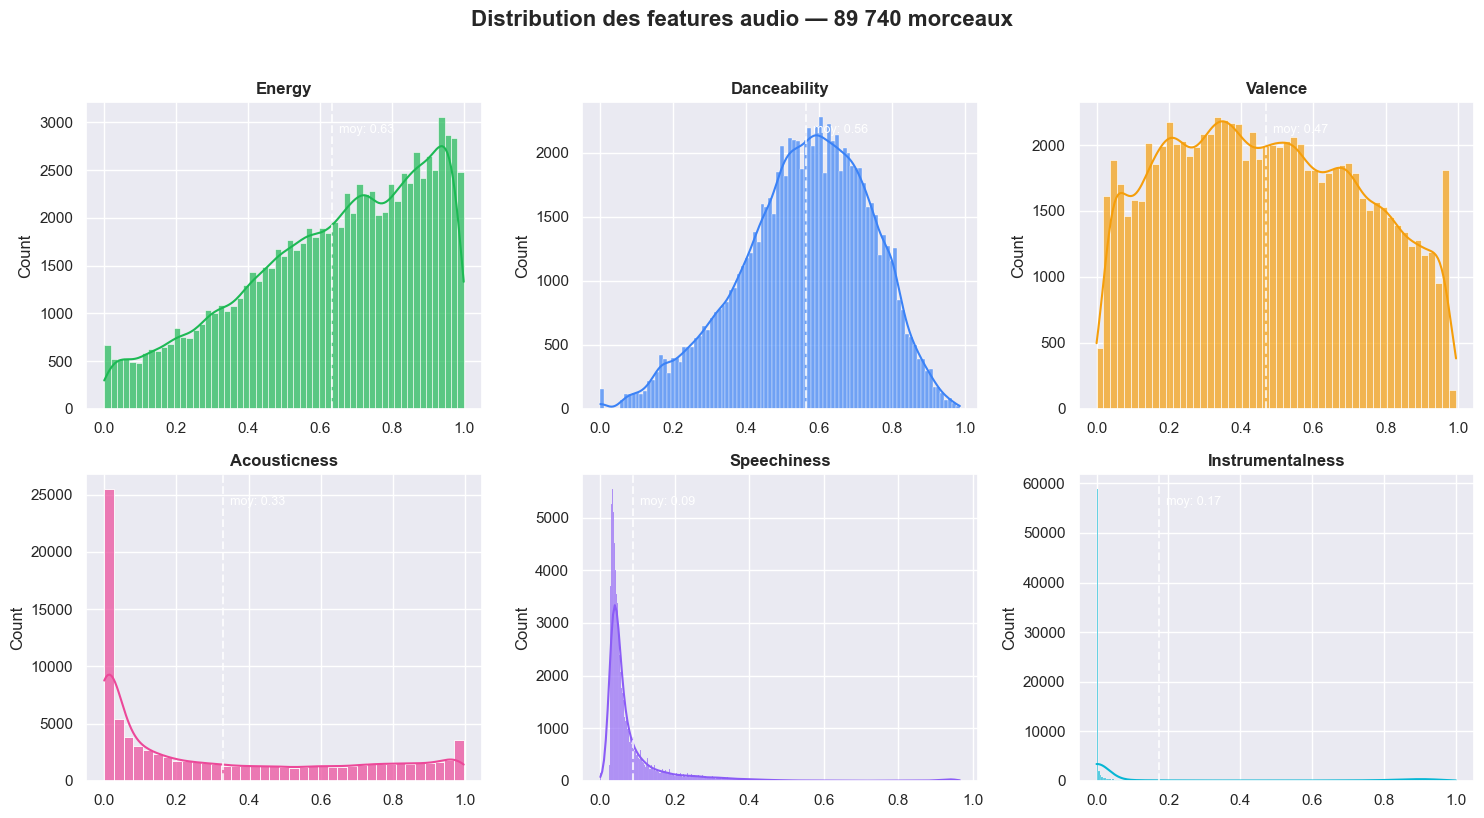

✅ Graphique sauvegardé !


In [4]:
# === VIZ 1 : Distribution des features audio ===

features = ['energy', 'danceability', 'valence', 
            'acousticness', 'speechiness', 'instrumentalness']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution des features audio — 89 740 morceaux', 
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#1DB954', '#3b82f6', '#f59e0b', '#ec4899', '#8b5cf6', '#06b6d4']

for ax, feature, color in zip(axes.flatten(), features, colors):
    sns.histplot(df[feature], ax=ax, kde=True, color=color, alpha=0.7)
    ax.set_title(feature.capitalize(), fontweight='bold')
    ax.set_xlabel('')
    mean_val = df[feature].mean()
    ax.axvline(mean_val, color='white', linestyle='--', alpha=0.8)
    ax.text(mean_val + 0.02, ax.get_ylim()[1]*0.9, 
            f'moy: {mean_val:.2f}', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('../data/viz_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique sauvegardé !")

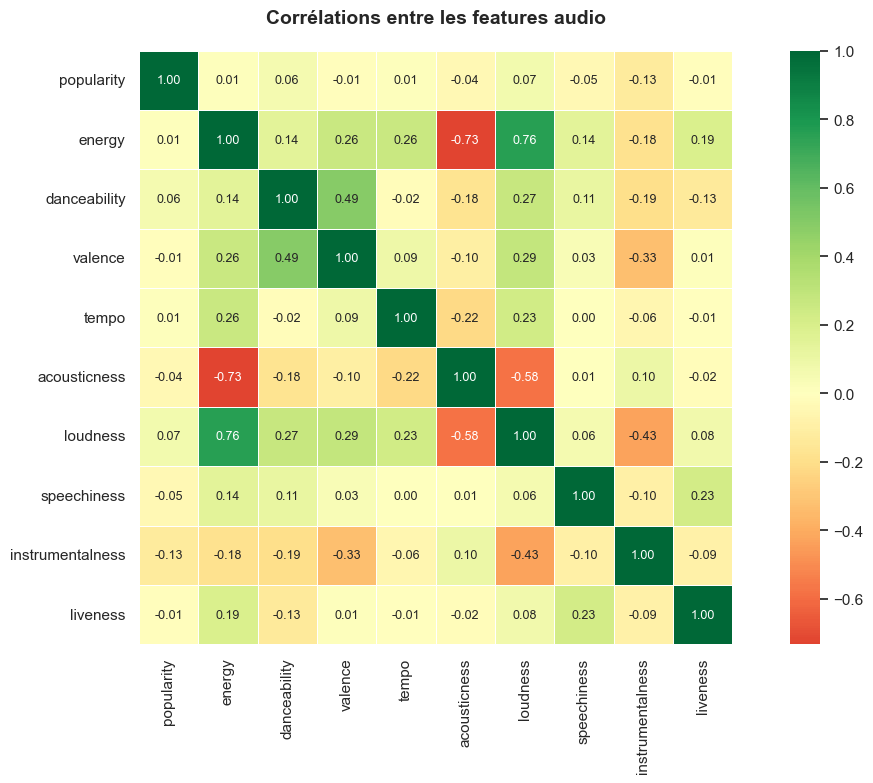

✅ Heatmap sauvegardée !


In [5]:
# === VIZ 2 : Heatmap de corrélation ===

numeric_cols = ['popularity', 'energy', 'danceability', 'valence', 
                'tempo', 'acousticness', 'loudness', 
                'speechiness', 'instrumentalness', 'liveness']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Corrélations entre les features audio', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/viz_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap sauvegardée !")

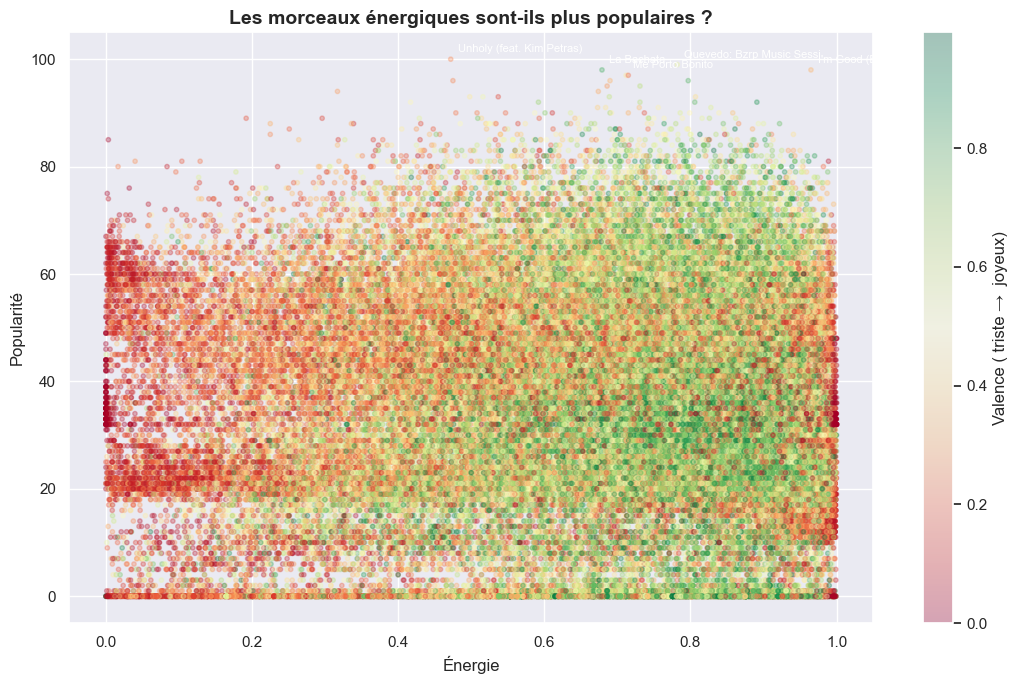

 Scatter sauvegardé !


In [10]:
# === VIZ 3 : Énergie vs Popularité ===

plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    df['energy'],
    df['popularity'],
    c=df['valence'],
    cmap='RdYlGn',
    alpha=0.3,
    s=10
)
plt.colorbar(scatter, label='Valence ( triste →  joyeux)')
plt.xlabel('Énergie', fontsize=12)
plt.ylabel('Popularité', fontsize=12)
plt.title('Les morceaux énergiques sont-ils plus populaires ?', 
          fontsize=14, fontweight='bold')

# Annoter le Top 5
top5 = df.nlargest(5, 'popularity')
for _, row in top5.iterrows():
    plt.annotate(
        row['track_name'][:25],
        (row['energy'], row['popularity']),
        fontsize=8, color='white',
        xytext=(5, 5), textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('../data/viz_energie_popularite.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter sauvegardé !")

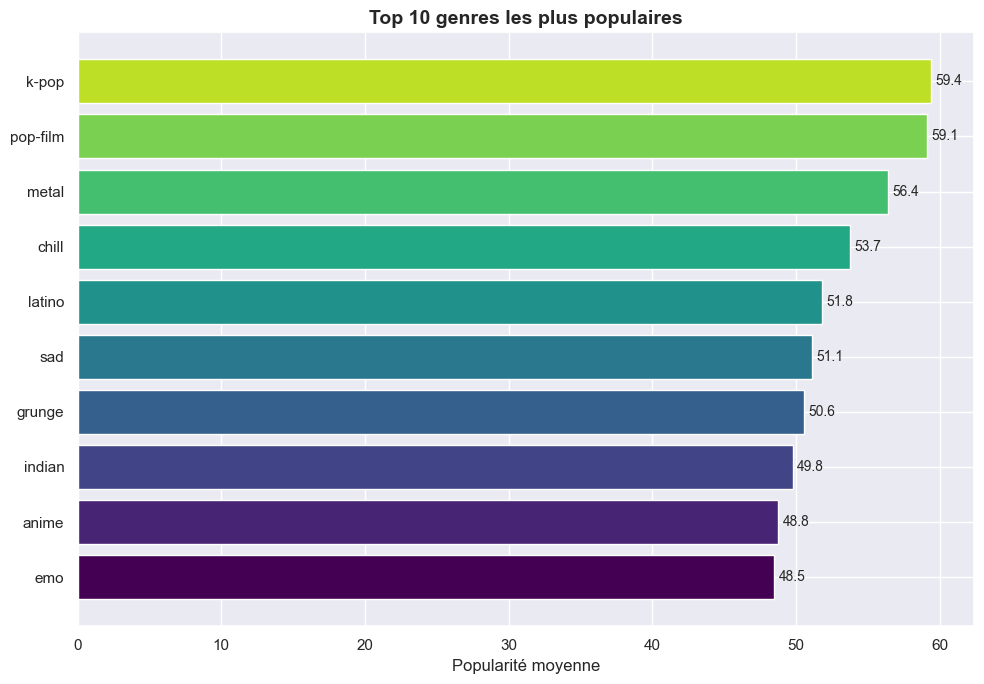

✅ Top genres sauvegardé !


In [7]:
# === VIZ 4 : Top 10 genres par popularité moyenne ===

top_genres = (df.groupby('track_genre')['popularity']
              .mean()
              .nlargest(10)
              .reset_index()
              .sort_values('popularity'))

plt.figure(figsize=(10, 7))
bars = plt.barh(top_genres['track_genre'], top_genres['popularity'],
                color=plt.cm.viridis([i/10 for i in range(10)]))

plt.xlabel('Popularité moyenne', fontsize=12)
plt.title('Top 10 genres les plus populaires', 
          fontsize=14, fontweight='bold')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, top_genres['popularity']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/viz_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Top genres sauvegardé !")

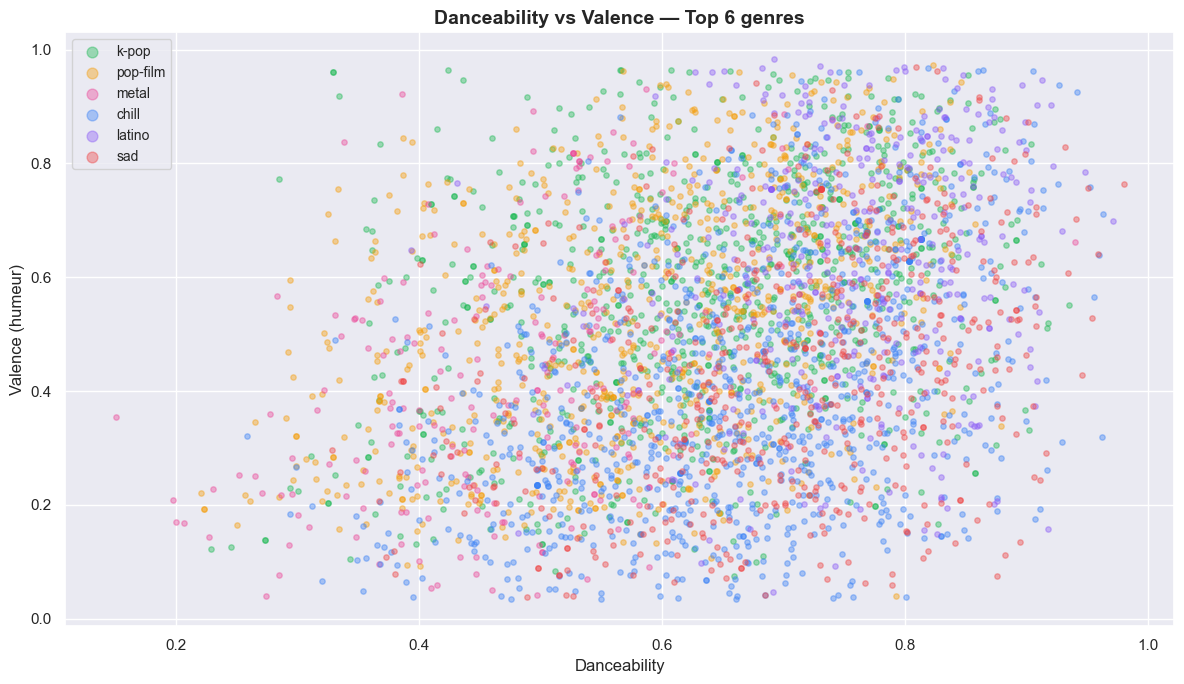

✅ Sauvegardé !


In [8]:
# === VIZ 5 : Danceability vs Valence par genre (Top 6) ===

top6_genres = (df.groupby('track_genre')['popularity']
               .mean().nlargest(6).index.tolist())

df_top6 = df[df['track_genre'].isin(top6_genres)]

plt.figure(figsize=(12, 7))
colors_genre = ['#1DB954', '#f59e0b', '#ec4899', '#3b82f6', '#8b5cf6', '#ef4444']

for genre, color in zip(top6_genres, colors_genre):
    subset = df_top6[df_top6['track_genre'] == genre]
    plt.scatter(subset['danceability'], subset['valence'],
                alpha=0.4, s=15, color=color, label=genre)

plt.xlabel('Danceability', fontsize=12)
plt.ylabel('Valence (humeur)', fontsize=12)
plt.title('Danceability vs Valence — Top 6 genres', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.savefig('../data/viz_dance_valence.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sauvegardé !")

In [11]:

# === RESUME DES INSIGHTS ===
print("=" * 55)
print("  DATAPULSE - Insights EDA")
print("=" * 55)
print(f"\nDataset propre : {df.shape[0]:,} morceaux, {df.shape[1]} colonnes")
print(f"Genres analyses : {df['track_genre'].nunique()}")
print(f"Artistes uniques : {df['artists'].nunique():,}")
print(f"\nCorrelations fortes detectees :")
print(f"   - Energy / Loudness      : +0.76")
print(f"   - Energy / Acousticness  : -0.73")
print(f"   - Danceability / Valence : +0.49")
print(f"\nGenre le plus populaire : K-pop (59.4/100)")
print(f"Surprise : Metal top 3 (56.4/100)")
print(f"Popularite != energie (correlation : +0.01)")
print(f"\nVisualisations sauvegardees dans data/")
print("=" * 55)

  DATAPULSE - Insights EDA

Dataset propre : 89,740 morceaux, 21 colonnes
Genres analyses : 113
Artistes uniques : 31,437

Correlations fortes detectees :
   - Energy / Loudness      : +0.76
   - Energy / Acousticness  : -0.73
   - Danceability / Valence : +0.49

Genre le plus populaire : K-pop (59.4/100)
Surprise : Metal top 3 (56.4/100)
Popularite != energie (correlation : +0.01)

Visualisations sauvegardees dans data/
